In [1]:
import pandas as pd
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

In [4]:
city = "ACC"
date = "190924"
path = f'votes/db/{city}/bulk_{city}_{date}.sqlite'
user = "communities"
con = sqlite3.connect(path)
cursor = con.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
for table in tables:
    print(table[0])

users
votes
sessions_private


In [8]:
sql= f"select * from votes"
votes_db = pd.read_sql(sql, con = con)
users_db = pd.read_sql(f"select * from users", con=con)

sessions = ['ACC_sel_200m_test_p3']
pmap_votes = votes_db[votes_db['session'].isin(sessions)]
print(len(pmap_votes))
pmap_votes = pd.merge(pmap_votes, users_db[['uid','u_name']], on='uid', how='inner')

56275


In [13]:
# Filter by date
if user == "planners":
    workshop_dates = ['29/8/2024'] # planners
    exclude_names = []
else:
    workshop_dates = ['14/8/2024','16/8/2024', '19/8/2024', '21/8/2024',
                 '22/8/2024', '23/8/2024']
    exclude_names = ['PHILIP', 'Abu Kamara ']
pmap_votes = pmap_votes[pmap_votes['date'].isin(workshop_dates)]
pmap_votes = pmap_votes[~pmap_votes['u_name'].isin(exclude_names)]
print(len(pmap_votes))

46738


In [17]:
pmap_votes = pmap_votes[['wins','loose']]
pmap_votes[['wins','loose']] = pmap_votes[['wins','loose']].astype(int)
pmap_votes.loc[:, 'pair'] = pmap_votes.apply(lambda row: tuple(sorted([row['wins'], row['loose']])), axis=1)

In [19]:
unique_pairs_count = pmap_votes['pair'].nunique()
print(f"Number of unique pairs: {unique_pairs_count}")

Number of unique pairs: 30935


In [21]:
duplicates = pmap_votes[pmap_votes.duplicated(subset='pair', keep=False)]
duplicates_count = duplicates.groupby('pair').size().reset_index(name='count')

26232
2
1944
[   2    3    4   35    6    5   70 1944    7]


In [25]:
random.seed(42)

# Compute unique_pairs_count and unique pairs
unique_pairs_count = pmap_votes['pair'].nunique()
unique_pairs = pmap_votes['pair'].unique()

# Create an empty DataFrame
pairs_df = pd.DataFrame(columns=['pair', 'winner', 'loser', 'win_ratio', 'dups'])

# Group pmap_votes by 'pair'
grouped = pmap_votes.groupby('pair')

# Iterate over unique pairs
for i, pair in enumerate(unique_pairs):
    dups = grouped.get_group(pair)
    print(i,end='\r')
    if len(dups) > 1:
        wins_count = dups['wins'].value_counts().to_dict()
        if wins_count == (len(dups)/2):
            winner = random.choice(pair)
        else:
            winner = max(wins_count, key=wins_count.get)
        winner_wins = wins_count.get(winner, 0)
        loser = pair[0] if pair[0] != winner else pair[1]
        win_ratio = float(winner_wins - (len(dups)-winner_wins))
    else:
        winner = dups['wins'].iloc[0]
        winner_wins = 1
        loser = pair[0] if pair[0] != winner else pair[1]
        win_ratio = 1
    new_row = pd.DataFrame([[pair, winner, loser, win_ratio, len(dups)]], columns=list(pairs_df.columns))
    pairs_df = pd.concat([pairs_df, new_row],ignore_index=True)
    
# Reset the index if needed
pairs_df.reset_index(drop=True, inplace=True)

In [26]:
print(len(pairs_df))
pairs_df.iloc[5000]

30935


pair         (32112, 42576)
winner                42576
loser                 32112
win_ratio               1.0
dups                      1
Name: 5000, dtype: object

In [27]:
sample_pair = (33485, 36206)
print(pmap_votes[(pmap_votes['pair'] == (sample_pair[0],sample_pair[1]))|
                 (pmap_votes['pair'] == (sample_pair[1],sample_pair[0]))])
# print(pairs_df.head(20))
print(pairs_df[pairs_df[('pair')] == sample_pair])

        wins  loose            pair
9469   33485  36206  (33485, 36206)
12539  36206  33485  (33485, 36206)
                pair winner  loser  win_ratio dups
5912  (33485, 36206)  33485  36206        0.0    2


In [28]:
pairs_df[['left', 'right']] = pairs_df['pair'].apply(lambda x: pd.Series([x[0], x[1]]))
# # Drop the original 'pair' column if needed
pairs_df.drop(columns=['pair'], inplace=True)
def determine_value(row):
    if row['winner'] == row['left']:
        return 0
    else:
        return 1
def get_winner_loser(row):
        if row.y == 0:
            return pd.Series([row.left, row.right])
        else:
            return pd.Series([row.right, row.left])
        
pairs_df.loc[:,'y'] = pairs_df.apply(determine_value, axis=1)
pairs_df.drop(columns=['winner','loser'], inplace=True)
pairs_df = pairs_df[['left', 'right','y', 'win_ratio', 'dups']]
pairs_df[['wins', 'lose']] = pairs_df.apply(get_winner_loser, axis=1)

In [29]:
def adjust_win_ratio(row, thresh):
    if row.y == 0:
        if row.win_ratio > (thresh):
            return (thresh*(-1))
        else:
            return row.win_ratio*(-1)
    else:
        if row.win_ratio > thresh:
            return thresh
        else:
            return row.win_ratio
    
pairs_df['adj_win_ratio'] = pairs_df.apply(adjust_win_ratio, thresh = 3, axis=1)

In [30]:
print(pairs_df[pairs_df['win_ratio']>3].head(10))
# print(pairs_df.head(10))

    left  right  y  win_ratio  dups   wins   lose  adj_win_ratio
0  33230  33697  1       35.0    35  33697  33230            3.0
1  37323  38245  0       35.0    35  37323  38245           -3.0
2  36186  38461  0       35.0    35  36186  38461           -3.0
3  34615  37786  0       35.0    35  34615  37786           -3.0
4  45768  50320  1       35.0    35  50320  45768            3.0
5  32085  36653  1       35.0    35  36653  32085            3.0
6  39399  41442  1     1524.0  1944  41442  39399            3.0
7  30721  39617  0       35.0    35  30721  39617           -3.0
8  46220  46222  0       35.0    35  46220  46222           -3.0
9  53045  55073  0       35.0    35  53045  55073           -3.0


In [184]:
# def normalize_column(column):
#     min_val = column.min()
#     max_val = column.max()
#     return 2 * ((column - min_val) / (max_val - min_val)) - 1

# pairs_df['n_win_ratio'] = normalize_column(pairs_df['adj_win_ratio'])

In [31]:
def add_fpath(row, side):
    if side == "left":
        return f"votes/2022/{city}/S1_200m/{city}_S1_200m_{row.left}.tif"
    else:
        return f"votes/2022/{city}/S1_200m/{city}_S1_200m_{row.right}.tif"

pairs_df['left'] = pairs_df.apply(add_fpath, side = 'left', axis = 1)
pairs_df['right'] = pairs_df.apply(add_fpath, side = 'right', axis = 1)

In [32]:
# print(pairs_df[(pairs_df['dups'] > 1)].head(20))
# print(pairs_df[pairs_df['win_ratio']>3])
print(pairs_df.head())
print(pairs_df['adj_win_ratio'].value_counts())

                                           left  \
0  votes/2022/ACC/S1_200m/ACC_S1_200m_33230.tif   
1  votes/2022/ACC/S1_200m/ACC_S1_200m_37323.tif   
2  votes/2022/ACC/S1_200m/ACC_S1_200m_36186.tif   
3  votes/2022/ACC/S1_200m/ACC_S1_200m_34615.tif   
4  votes/2022/ACC/S1_200m/ACC_S1_200m_45768.tif   

                                          right  y  win_ratio dups   wins  \
0  votes/2022/ACC/S1_200m/ACC_S1_200m_33697.tif  1       35.0   35  33697   
1  votes/2022/ACC/S1_200m/ACC_S1_200m_38245.tif  0       35.0   35  37323   
2  votes/2022/ACC/S1_200m/ACC_S1_200m_38461.tif  0       35.0   35  36186   
3  votes/2022/ACC/S1_200m/ACC_S1_200m_37786.tif  0       35.0   35  34615   
4  votes/2022/ACC/S1_200m/ACC_S1_200m_50320.tif  1       35.0   35  50320   

    lose  adj_win_ratio  
0  33230            3.0  
1  38245           -3.0  
2  38461           -3.0  
3  37786           -3.0  
4  45768            3.0  
-1.0    11159
 1.0    10319
-2.0     2927
 0.0     2807
 2.0     2598
-3.0

In [33]:
print(pairs_df['adj_win_ratio'].mean())
print(pairs_df['adj_win_ratio'].std())

-0.05492160982705673
1.3164476694656793


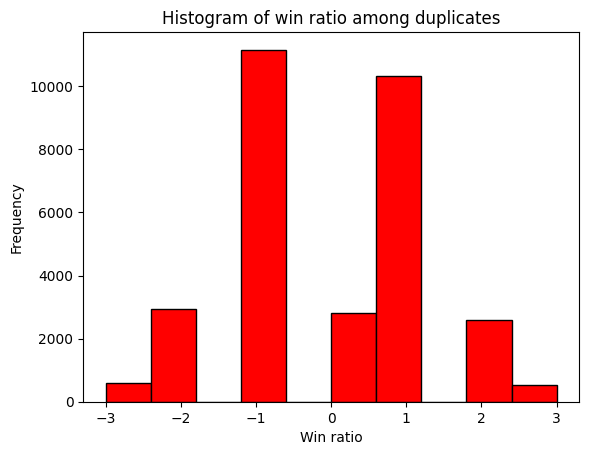

In [34]:
# Plotting the histogram
plt.hist(pairs_df['adj_win_ratio'], bins=10, color='red', edgecolor='black')
# Adding labels and title
plt.xlabel('Win ratio')
plt.ylabel('Frequency')
plt.title('Histogram of win ratio among duplicates')

plt.show()

In [35]:
# Calculate weights
win_counts = pairs_df['wins'].value_counts()
lose_counts = pairs_df['lose'].value_counts()
overall_counts = win_counts.add(lose_counts, fill_value=0)
overall_counts = overall_counts.reset_index()
overall_counts.columns = ['ID', 'count']
# overall_counts['weight'] = 1 / overall_counts['count']
overall_counts['weight'] = np.log(overall_counts['count'] + 1)
# Join weights back to pairs
pmap_votes_ct = pairs_df.merge(overall_counts[['ID','weight']], left_on='wins', right_on='ID', suffixes=('', '_wins')).rename(columns={'ID':'ID_wins','weight':'weight_wins'})
# pmap_votes_ct = pmap_votes_ct.rename(columns={'ID':'ID_wins','weight':'weight_wins'})
pmap_votes_ct = pmap_votes_ct.merge(overall_counts[['ID','weight']], left_on='lose', right_on='ID', suffixes=('', '_lose')).rename(columns={'ID':'ID_lose','weight':'weight_lose'})
pmap_votes_ct['weight'] = (pmap_votes_ct['weight_wins'])+(pmap_votes_ct['weight_lose'])
pmap_votes_ct = pmap_votes_ct[['left', 'right', 'y', 'wins', 'lose', 'weight' ]]

                                               left  \
2571   votes/2022/ACC/S1_200m/ACC_S1_200m_34154.tif   
26499  votes/2022/ACC/S1_200m/ACC_S1_200m_55099.tif   
19313  votes/2022/ACC/S1_200m/ACC_S1_200m_46007.tif   
5631   votes/2022/ACC/S1_200m/ACC_S1_200m_32092.tif   
30574  votes/2022/ACC/S1_200m/ACC_S1_200m_38220.tif   

                                              right  y   wins   lose    weight  
2571   votes/2022/ACC/S1_200m/ACC_S1_200m_40299.tif  1  40299  34154  9.621125  
26499  votes/2022/ACC/S1_200m/ACC_S1_200m_55773.tif  0  55099  55773  8.861492  
19313  votes/2022/ACC/S1_200m/ACC_S1_200m_63720.tif  1  63720  46007  9.472397  
5631   votes/2022/ACC/S1_200m/ACC_S1_200m_37786.tif  0  32092  37786  9.382612  
30574  votes/2022/ACC/S1_200m/ACC_S1_200m_42309.tif  0  38220  42309  7.843064  
7.21890970761906
9.735068900911164


<AxesSubplot: >

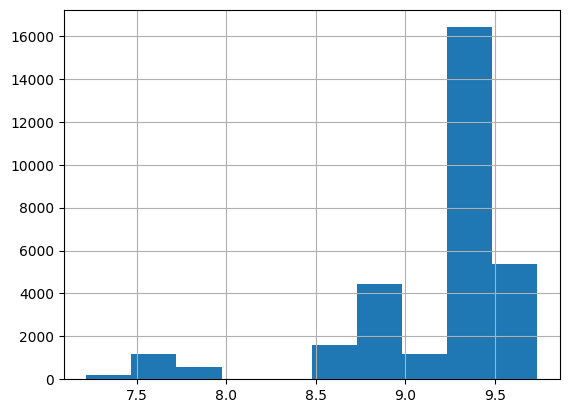

In [36]:
print(pmap_votes_ct.sample(frac=1).head())
print(min(pmap_votes_ct['weight']))
print(max(pmap_votes_ct['weight']))
pmap_votes_ct['weight'].hist()

In [37]:
out_path = f'votes/db/{city}/{city}_voterAI.db'
con = sqlite3.connect(out_path)
out_tbl = f'{city}_{user}_votes'
pmap_votes_ct.to_sql(out_tbl, con = con, if_exists= 'replace')

30935